# Explore SDSSRM-XCS Scatter: Dependence on hot-ICM morphology

This section of the project explores potential reasons and diagnostics of galaxy cluster/group scaling relation scatter using the new SDSSRM-XCS relations constructed in this work from the properties measured in the first paper of this series [(Turner et al. 2024)](https://ui.adsabs.harvard.edu/abs/2025MNRAS.tmp...10T/abstract).

Here we examine several new SDSSRM-XCS scaling relations to see whether there are obvious correlations between the scatter of particular data points and the morphology metrics of the cluster they represent; previous work has shown that different morphological 'types' of clusters can produce distinctly different scaling relation slopes/normalisations if they are fit separately (e.g. [Mantz et al. 2016](https://ui.adsabs.harvard.edu/abs/2016MNRAS.463.3582M/abstract)).

Scaling relation fits were performed using the XGA interface to the R scaling-relation fitting package LIRA, see the paper for full details.

## Main takeaways

In summary:
*  

## Import Statements

In [1]:
import pandas as pd
pd.set_option('display.max_columns', 500)
import numpy as np
from astropy.units import Quantity
from astropy.cosmology import LambdaCDM
import pickle
import matplotlib
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm
from matplotlib.ticker import FuncFormatter

# This adds the directory above to the path, allowing me to import the common functions that I've written in
#  common.py - this just saves me repeating boring code and makes sure its all consistent
import sys
sys.path.insert(0, '..')
from common import xcs_cosmo

import xga
xga.__version__

'v0.5.3+358.gb820a764'

## Setting up useful constants

Here we set up variable values that will be used repeatedly throughout this notebook, to make it easier to globally change them in the future if it becomes necessary:

In [2]:
# Color map to use for centroid shift data point colouring
CEN_SHIFT_CMAP = 'magma'
# And the equivalent for concentration colouring
CONC_CMAP = "managua"

## Loading data files and relations

We load the 'base' SDSSRM-XCS sample file, containing some basic information about galaxy cluster names, positions, and redshifts. More importantly, we load the morphology metric results newly measured for this work.

The new SDSSRM-XCS scaling relations (constructed in the course of this work) which we will explore the scatter for in this notebook are also loaded in here - note that we do not load every single relation, but rather make a representative selection. Please see the individual notebooks in the 'new_sdssrm_relations' directory for full details of the relations.

### Data files

#### SDSSRM-XCS base sample

In [3]:
sdssxcs_base = pd.read_csv("../../sample_files/SDSSRM-XCS_base_sample.csv")
sdssxcs_base.head(6)

,name,MEM_MATCH_ID,xapa_ra,xapa_dec,rm_ra,rm_dec,z,r500,r500-,r500+,richness,richness_err,XCS_NAME,R_LAMBDA,xmm_targeted,xmm_serendipitous
0,SDSSXCS-124,124,0.80058,-6.09182,0.798261,-6.091694,0.2475,1181.028,21.202,23.203,109.550,4.490,XMMXCS J000312.1-060530.5,1.018410,True,False
1,SDSSXCS-2789,2789,0.95554,2.06802,0.956981,2.066469,0.1053,1007.861,17.194,17.202,38.904,2.830,XMMXCS J000349.3+020404.8,0.827942,True,False
2,SDSSXCS-290,290,2.72264,29.16102,2.714137,29.161154,0.3485,913.052,30.879,31.210,105.096,5.994,XMMXCS J001053.4+290939.6,1.009990,True,False
3,SDSSXCS-1018,1018,4.40633,-0.87619,4.406711,-0.878340,0.2144,902.259,22.445,23.366,56.997,3.219,XMMXCS J001737.5-005234.2,0.893655,False,True
4,SDSSXCS-134,134,4.90839,3.60982,4.911069,3.599257,0.2773,1123.321,19.219,19.226,108.604,4.792,XMMXCS J001938.0+033635.3,1.016645,True,False
5,SDSSXCS-119,119,8.46470,-7.86290,8.471426,-7.869543,0.3042,944.275,46.422,46.747,128.192,5.697,XMMXCS J003351.5-075146.4,1.050926,True,False


#### SDSSRM-XCS morphology metrics

In [4]:
sdssxcs_morph = pd.read_csv("../../outputs/result_files/xmm_centshift_concentration.csv")
sdssxcs_morph.head(6)

,name,cen_shift,cen_shift-,cen_shift+,concentration,concentration-,concentration+
0,SDSSXCS-124,0.0338,0.0009,0.0008,0.1695,0.0024,0.0026
1,SDSSXCS-2789,0.0888,0.0012,0.0012,0.1066,0.0024,0.0033
2,SDSSXCS-290,0.0096,0.0025,0.0026,0.2610,0.0134,0.0111
3,SDSSXCS-1018,0.0370,0.0019,0.0022,0.2846,0.0077,0.0091
4,SDSSXCS-134,0.0779,0.0012,0.0011,0.1737,0.0037,0.0029
5,SDSSXCS-119,0.0435,0.0082,0.0074,0.0943,0.0130,0.0107


#### Combining tables

In [5]:
sdssxcs_samp = pd.merge(sdssxcs_base, sdssxcs_morph, left_on='name', right_on='name', how='outer')
sdssxcs_samp.head(6)

,name,MEM_MATCH_ID,xapa_ra,xapa_dec,rm_ra,rm_dec,z,r500,r500-,r500+,richness,richness_err,XCS_NAME,R_LAMBDA,xmm_targeted,xmm_serendipitous,cen_shift,cen_shift-,cen_shift+,concentration,concentration-,concentration+
0,SDSSXCS-1018,1018,4.40633,-0.87619,4.406711,-0.878340,0.2144,902.259,22.445,23.366,56.997,3.219,XMMXCS J001737.5-005234.2,0.893655,False,True,0.0370,0.0019,0.0022,0.2846,0.0077,0.0091
1,SDSSXCS-10223,10223,327.85131,-5.45000,327.845677,-5.447874,0.1402,746.039,26.739,36.742,20.049,1.960,XMMXCS J215124.3-052659.9,0.725136,False,True,0.0473,0.0042,0.0028,0.0813,0.0071,0.0079
2,SDSSXCS-103,103,117.70904,17.69577,117.753138,17.631602,0.1839,872.820,22.495,22.601,112.266,5.978,XMMXCS J075050.1+174144.7,1.023409,True,False,0.0339,0.0016,0.0020,0.0802,0.0033,0.0028
3,SDSSXCS-10401,10401,179.61596,26.49539,179.607495,26.498043,0.1411,609.736,22.255,21.940,24.794,2.297,XMMXCS J115827.8+262943.4,0.756602,False,True,0.0115,0.0027,0.0035,0.1575,0.0075,0.0096
4,SDSSXCS-10897,10897,170.22943,43.30579,170.232248,43.307696,0.1850,484.298,29.406,51.297,23.604,2.235,XMMXCS J112055.0+431820.8,0.749197,False,True,0.0326,0.0101,0.0133,0.1663,0.0199,0.0258
5,SDSSXCS-110,110,336.52107,17.37229,336.509285,17.379739,0.1136,1172.594,17.805,17.804,74.281,2.668,XMMXCS J222605.0+172220.2,0.942270,True,False,0.0600,0.0005,0.0004,0.2288,0.0013,0.0015


### SDSSRM-XCS scaling relations

#### $M^{\rm{tot}}_{500}$-$T_{\rm{X,500}}$

In [6]:
with open('../../outputs/scaling_relations/sdssrm-xcs_new/mtot-tx/turner2025_mtot500_tx500.xgarel', 'rb') as scalo:
    mtot500_tx500 = pickle.load(scalo)

#### $M^{\rm{tot}}_{2500}$-$T_{\rm{X,2500}}$

In [7]:
with open('../../outputs/scaling_relations/sdssrm-xcs_new/mtot-tx/turner2025_mtot2500_tx2500.xgarel', 'rb') as scalo:
    mtot2500_tx2500 = pickle.load(scalo)

#### $M^{\rm{tot}}_{500}$-$L^{\rm{bol}}_{\rm{X,500ce}}$

In [8]:
with open('../../outputs/scaling_relations/sdssrm-xcs_new/mtot-lx/turner2025_mtot500_lxbol_500ce.xgarel', 'rb') as scalo:
    mtot500_lxbol_500ce = pickle.load(scalo)

#### $M^{\rm{tot}}_{2500}$-$L^{\rm{bol}}_{\rm{X,2500}}$

In [9]:
with open('../../outputs/scaling_relations/sdssrm-xcs_new/mtot-lx/turner2025_mtot2500_lxbol_2500.xgarel', 'rb') as scalo:
    mtot2500_lxbol_2500 = pickle.load(scalo)

#### $M^{\rm{tot}}_{500}$-$\lambda_{\rm{RM}}$

In [10]:
with open('../../outputs/scaling_relations/sdssrm-xcs_new/mtot-richness/turner2025_mtot500_richness.xgarel', 'rb') as scalo:
    mtot500_rich = pickle.load(scalo)

#### $M^{\rm{gas}}_{500}$-$T_{\rm{X,500}}$

In [11]:
with open('../../outputs/scaling_relations/sdssrm-xcs_new/mgas-tx/turner2025_mgas500_tx500.xgarel', 'rb') as scalo:
    mgas500_tx500 = pickle.load(scalo)

#### $M^{\rm{gas}}_{2500}$-$T_{\rm{X,2500}}$

In [12]:
with open('../../outputs/scaling_relations/sdssrm-xcs_new/mgas-tx/turner2025_mgas2500_tx2500.xgarel', 'rb') as scalo:
    mgas2500_tx2500 = pickle.load(scalo)

#### $M^{\rm{gas}}_{500}$-$L^{\rm{bol}}_{\rm{X,500ce}}$

In [13]:
with open('../../outputs/scaling_relations/sdssrm-xcs_new/mgas-lx/turner2025_mgas500_lxbol_500ce.xgarel', 'rb') as scalo:
    mgas500_lxbol_500ce = pickle.load(scalo)

#### $M^{\rm{gas}}_{2500}$-$L^{\rm{bol}}_{\rm{X,2500}}$

In [14]:
with open('../../outputs/scaling_relations/sdssrm-xcs_new/mgas-lx/turner2025_mgas2500_lxbol_2500.xgarel', 'rb') as scalo:
    mgas2500_lxbol_2500 = pickle.load(scalo)

## Examining SDSSRM-XCS scaling relations with hot ICM morphology context

Here we will visualise a selection of SDSSRM-XCS scaling relations with their data points coloured by morphology metric values - this should make for a good visual indicator of whether scatter is being significantly effected by different morphologies. For instance, if it is clear that different morphologies are following distinctly different 'tracks' in the parameter space of the scaling relation.

### $M^{\rm{tot}}_{500}$-$T_{\rm{X,500}}$ 

First we examine the SDSSRM-XCS total mass - temperature mass observable relation (MOR) measured within $R_{500}$, as it is one of the lowest overall scatter relations we construct in this work. Other versions of the relation between these two parameters, e.g. the $R_{2500}$ skew, or the scatter-dominating-removed variant (see the total mass to temperature jackknifing assessment notebook), exhibit lower measured scatter, but this version includes all data points and is likely to be one of the more commonly used, hence why we have chosen it.

#### Centroid shift

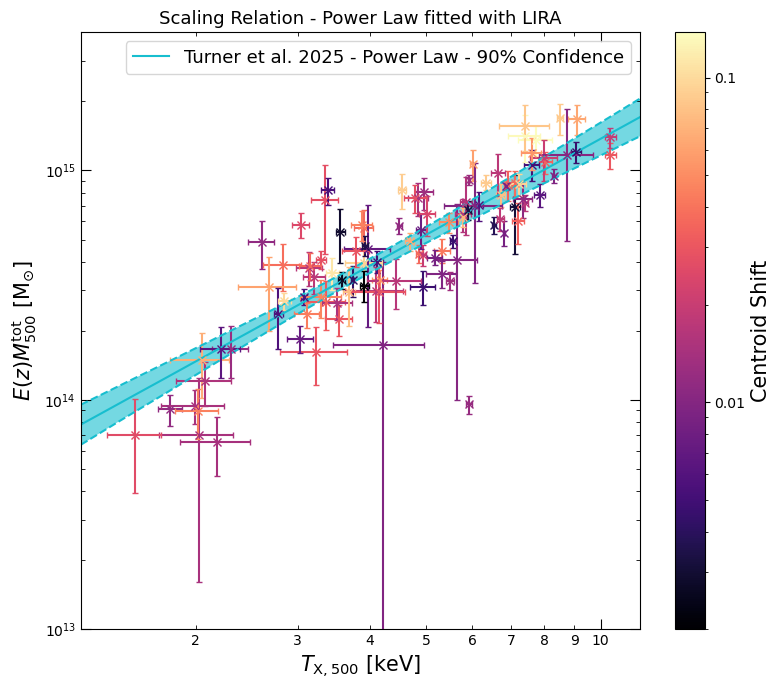

In [15]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mtot500_tx500.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
cent_shift = sdssxcs_samp.loc[pnt_samp_ind, 'cen_shift'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mtot500_tx500._third_dim_info = cent_shift
mtot500_tx500._third_dim_name = "Centroid Shift"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their centroid shift, but also log-scaling the
#  colorbar axis to make differentiating between different centroid shifts easier
mtot500_tx500.view(figsize=(8, 7), y_lims=Quantity([1e+13, 4e+15], 'Msun'), third_dim_cmap=CEN_SHIFT_CMAP, 
                   third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

#### Concentration

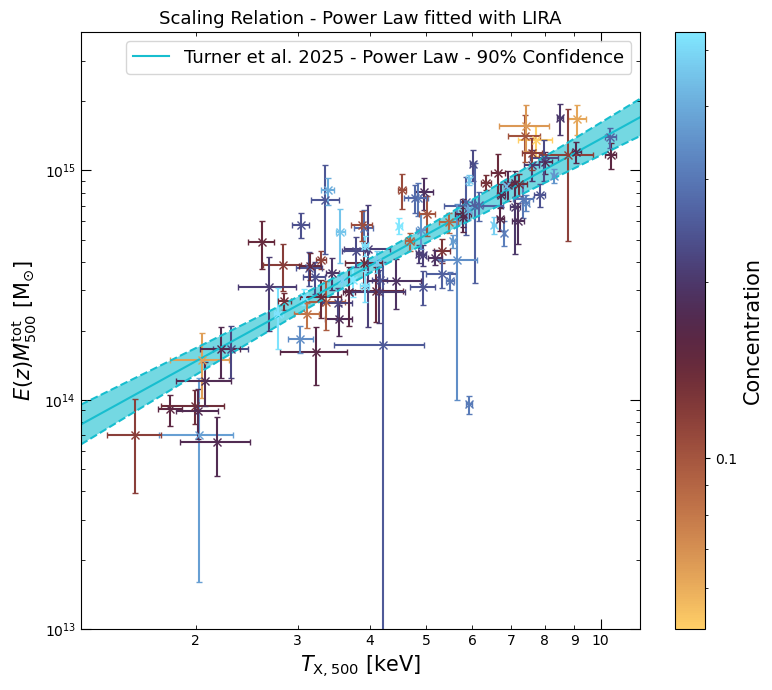

In [16]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mtot500_tx500.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
conc = sdssxcs_samp.loc[pnt_samp_ind, 'concentration'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mtot500_tx500._third_dim_info = conc
mtot500_tx500._third_dim_name = "Concentration"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their concentration, but also log-scaling the
#  colorbar axis to make differentiating between different concentration easier
mtot500_tx500.view(figsize=(8, 7), y_lims=Quantity([1e+13, 4e+15], 'Msun'), third_dim_cmap=CONC_CMAP, 
                   third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

### $M^{\rm{tot}}_{2500}$-$T_{\rm{X,2500}}$ 

We will also look at the $R_{2500}$ skew of the $M_{\rm{tot}}$-$T_{\rm{X}}$ relation.

#### Centroid shift

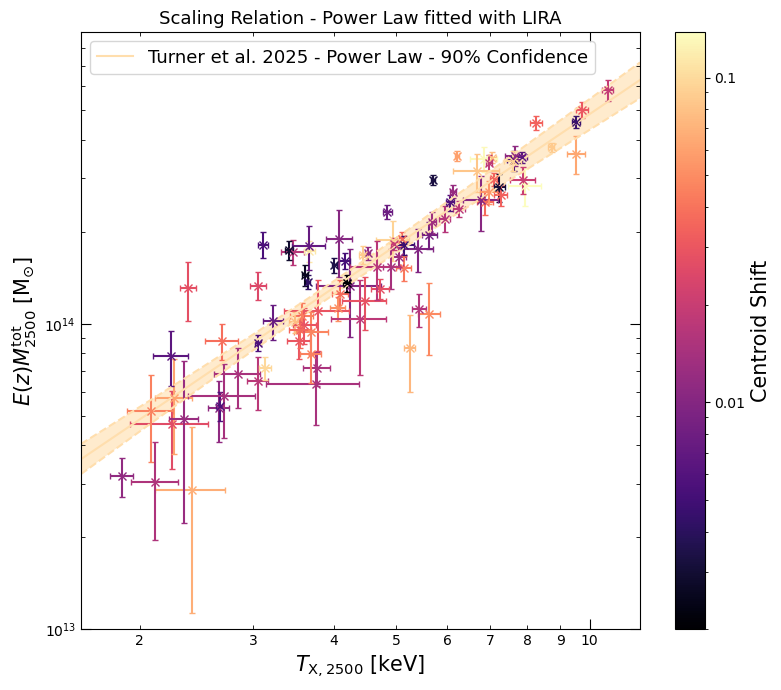

In [17]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mtot2500_tx2500.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
cent_shift = sdssxcs_samp.loc[pnt_samp_ind, 'cen_shift'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mtot2500_tx2500._third_dim_info = cent_shift
mtot2500_tx2500._third_dim_name = "Centroid Shift"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their centroid shift, but also log-scaling the
#  colorbar axis to make differentiating between different centroid shifts easier
mtot2500_tx2500.view(figsize=(8, 7), y_lims=Quantity([1e+13, 9e+14], 'Msun'), third_dim_cmap=CEN_SHIFT_CMAP, 
                     third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

#### Concentration

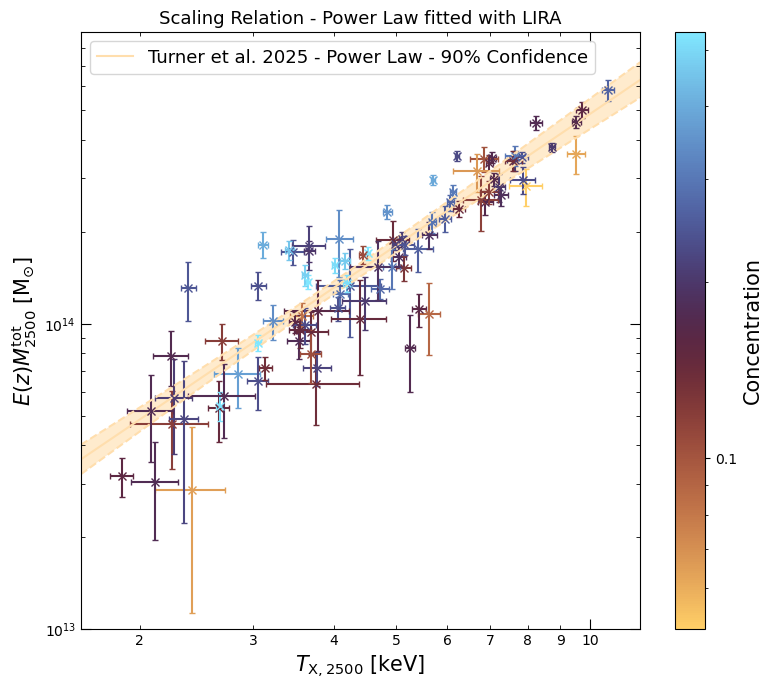

In [18]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mtot2500_tx2500.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
conc = sdssxcs_samp.loc[pnt_samp_ind, 'concentration'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mtot2500_tx2500._third_dim_info = conc
mtot2500_tx2500._third_dim_name = "Concentration"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their concentration, but also log-scaling the
#  colorbar axis to make differentiating between different concentration easier
mtot2500_tx2500.view(figsize=(8, 7), y_lims=Quantity([1e+13, 9e+14], 'Msun'), third_dim_cmap=CONC_CMAP, 
                     third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

### $M^{\rm{tot}}_{500}$-$L^{\rm{bol}}_{\rm{X,500ce}}$

#### Centroid shift

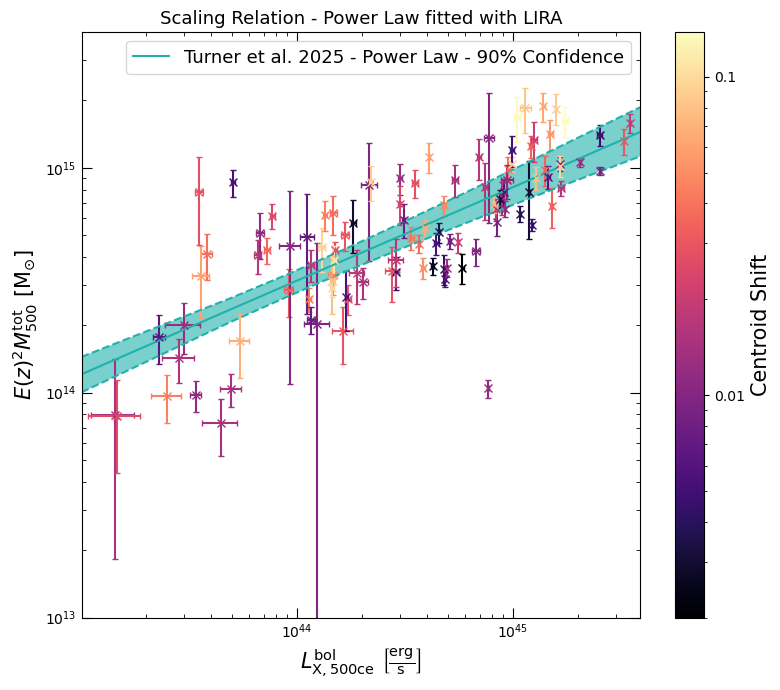

In [19]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mtot500_lxbol_500ce.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
cent_shift = sdssxcs_samp.loc[pnt_samp_ind, 'cen_shift'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mtot500_lxbol_500ce._third_dim_info = cent_shift
mtot500_lxbol_500ce._third_dim_name = "Centroid Shift"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their centroid shift, but also log-scaling the
#  colorbar axis to make differentiating between different centroid shifts easier
mtot500_lxbol_500ce.view(figsize=(8, 7), y_lims=Quantity([1e+13, 4e+15], 'Msun'), third_dim_cmap=CEN_SHIFT_CMAP, 
                         third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

#### Concentration

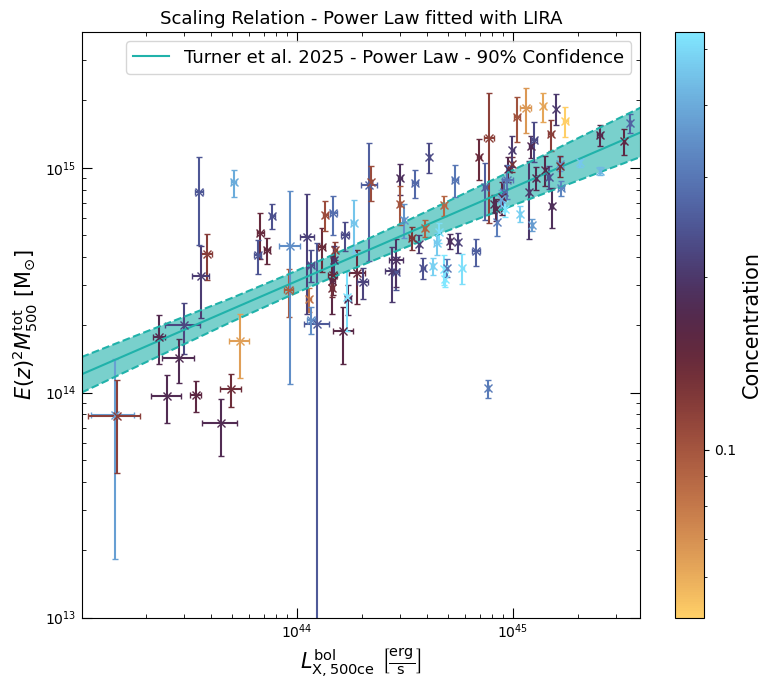

In [20]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mtot500_lxbol_500ce.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
conc = sdssxcs_samp.loc[pnt_samp_ind, 'concentration'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mtot500_lxbol_500ce._third_dim_info = conc
mtot500_lxbol_500ce._third_dim_name = "Concentration"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their concentration, but also log-scaling the
#  colorbar axis to make differentiating between different concentration easier
mtot500_lxbol_500ce.view(figsize=(8, 7), y_lims=Quantity([1e+13, 4e+15], 'Msun'), third_dim_cmap=CONC_CMAP, 
                         third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

### $M^{\rm{tot}}_{2500}$-$L^{\rm{bol}}_{\rm{X,2500}}$

#### Centroid shift

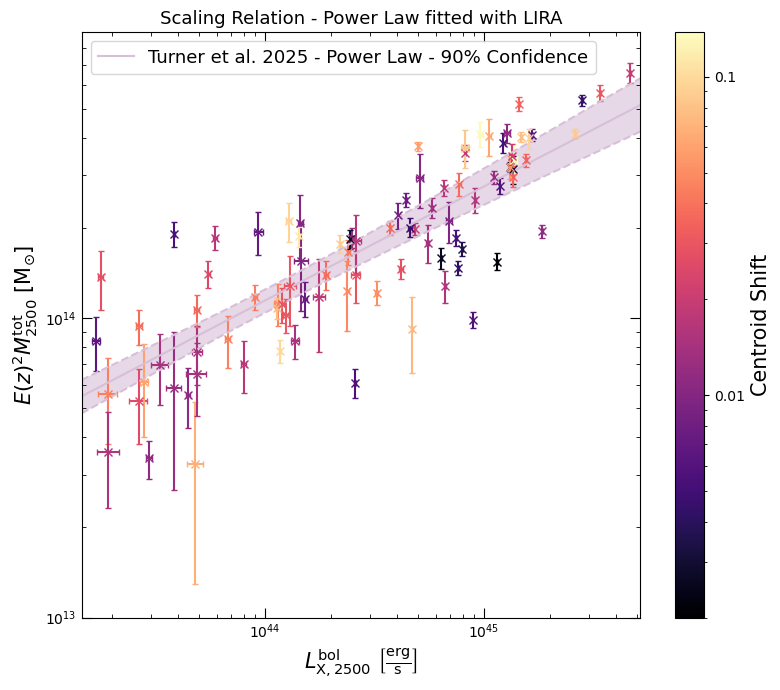

In [21]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mtot2500_lxbol_2500.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
cent_shift = sdssxcs_samp.loc[pnt_samp_ind, 'cen_shift'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mtot2500_lxbol_2500._third_dim_info = cent_shift
mtot2500_lxbol_2500._third_dim_name = "Centroid Shift"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their centroid shift, but also log-scaling the
#  colorbar axis to make differentiating between different centroid shifts easier
mtot2500_lxbol_2500.view(figsize=(8, 7), y_lims=Quantity([1e+13, 9e+14], 'Msun'), third_dim_cmap=CEN_SHIFT_CMAP, 
                         third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

#### Concentration

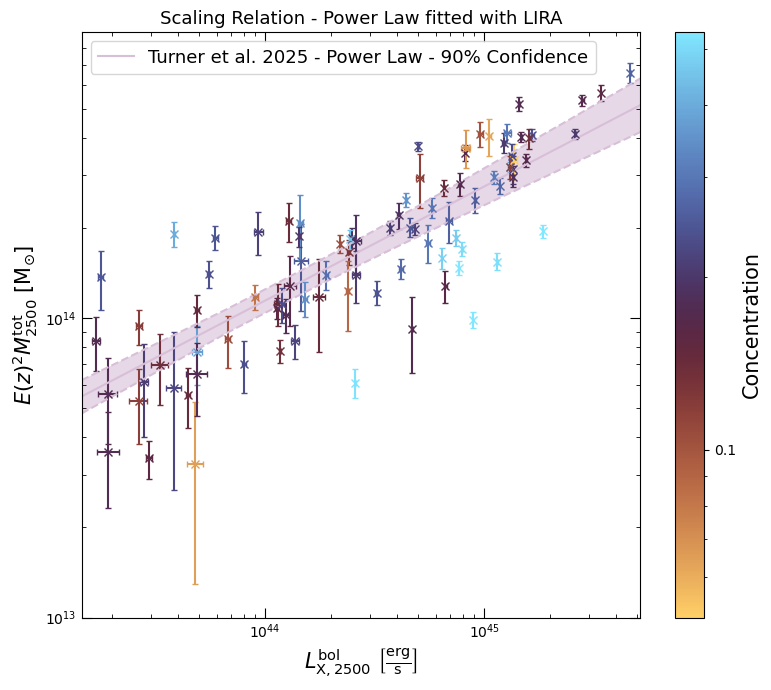

In [22]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mtot2500_lxbol_2500.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
conc = sdssxcs_samp.loc[pnt_samp_ind, 'concentration'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mtot2500_lxbol_2500._third_dim_info = conc
mtot2500_lxbol_2500._third_dim_name = "Concentration"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their concentration, but also log-scaling the
#  colorbar axis to make differentiating between different concentration easier
mtot2500_lxbol_2500.view(figsize=(8, 7), y_lims=Quantity([1e+13, 9e+14], 'Msun'), third_dim_cmap=CONC_CMAP, 
                         third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

### $M^{\rm{tot}}_{500}$-$\lambda_{\rm{RM}}$

#### Centroid shift

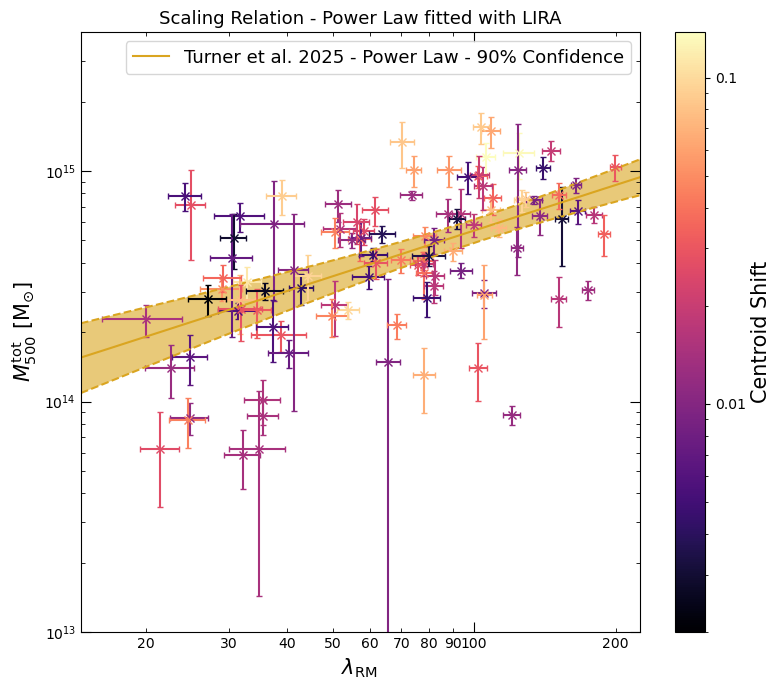

In [23]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mtot500_rich.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
cent_shift = sdssxcs_samp.loc[pnt_samp_ind, 'cen_shift'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mtot500_rich._third_dim_info = cent_shift
mtot500_rich._third_dim_name = "Centroid Shift"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their centroid shift, but also log-scaling the
#  colorbar axis to make differentiating between different centroid shifts easier
mtot500_rich.view(figsize=(8, 7), y_lims=Quantity([1e+13, 4e+15], 'Msun'), third_dim_cmap=CEN_SHIFT_CMAP, 
                  third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

#### Concentration

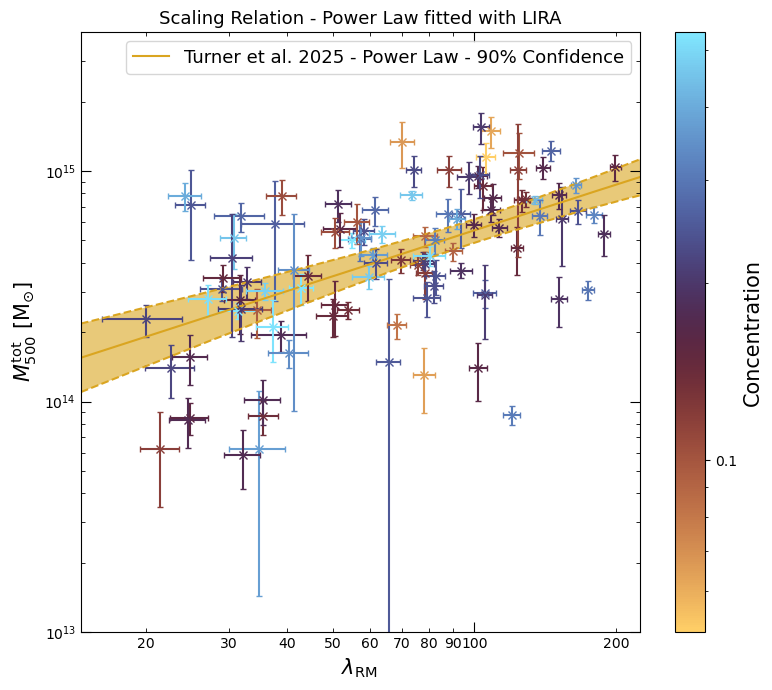

In [24]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mtot500_rich.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
conc = sdssxcs_samp.loc[pnt_samp_ind, 'concentration'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mtot500_rich._third_dim_info = conc
mtot500_rich._third_dim_name = "Concentration"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their concentration, but also log-scaling the
#  colorbar axis to make differentiating between different concentration easier
mtot500_rich.view(figsize=(8, 7), y_lims=Quantity([1e+13, 4e+15], 'Msun'), third_dim_cmap=CONC_CMAP, 
                  third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

### $M^{\rm{gas}}_{500}$-$L^{\rm{bol}}_{\rm{X,500ce}}$

#### Centroid shift

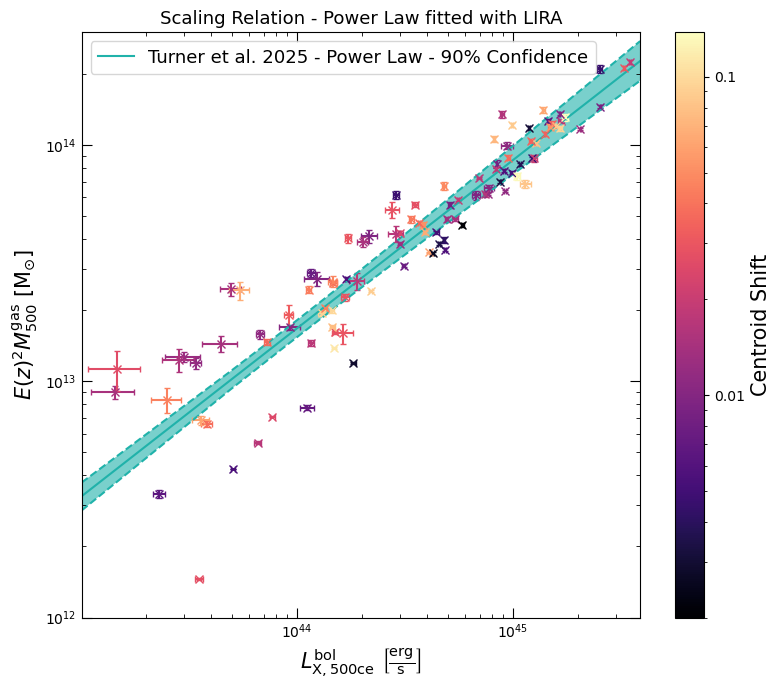

In [25]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mgas500_lxbol_500ce.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
cent_shift = sdssxcs_samp.loc[pnt_samp_ind, 'cen_shift'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mgas500_lxbol_500ce._third_dim_info = cent_shift
mgas500_lxbol_500ce._third_dim_name = "Centroid Shift"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their centroid shift, but also log-scaling the
#  colorbar axis to make differentiating between different centroid shifts easier
mgas500_lxbol_500ce.view(figsize=(8, 7), y_lims=Quantity([1e+12, 3e+14], 'Msun'), third_dim_cmap=CEN_SHIFT_CMAP, 
                         third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

#### Concentration

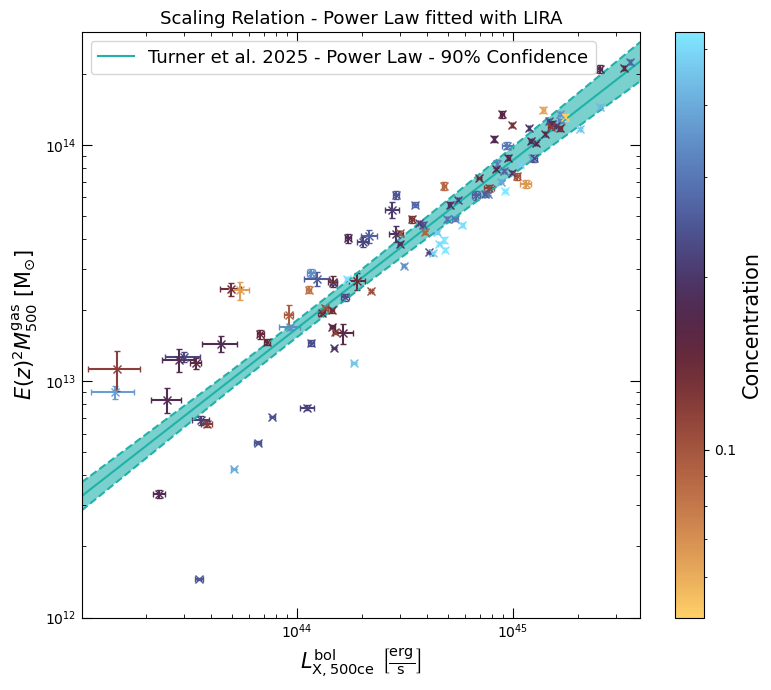

In [26]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mgas500_lxbol_500ce.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
conc = sdssxcs_samp.loc[pnt_samp_ind, 'concentration'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mgas500_lxbol_500ce._third_dim_info = conc
mgas500_lxbol_500ce._third_dim_name = "Concentration"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their concentration, but also log-scaling the
#  colorbar axis to make differentiating between different concentration easier
mgas500_lxbol_500ce.view(figsize=(8, 7), y_lims=Quantity([1e+12, 3e+14], 'Msun'), third_dim_cmap=CONC_CMAP, 
                         third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

### $M^{\rm{tot}}_{2500}$-$L^{\rm{bol}}_{\rm{X,2500}}$

#### Centroid shift

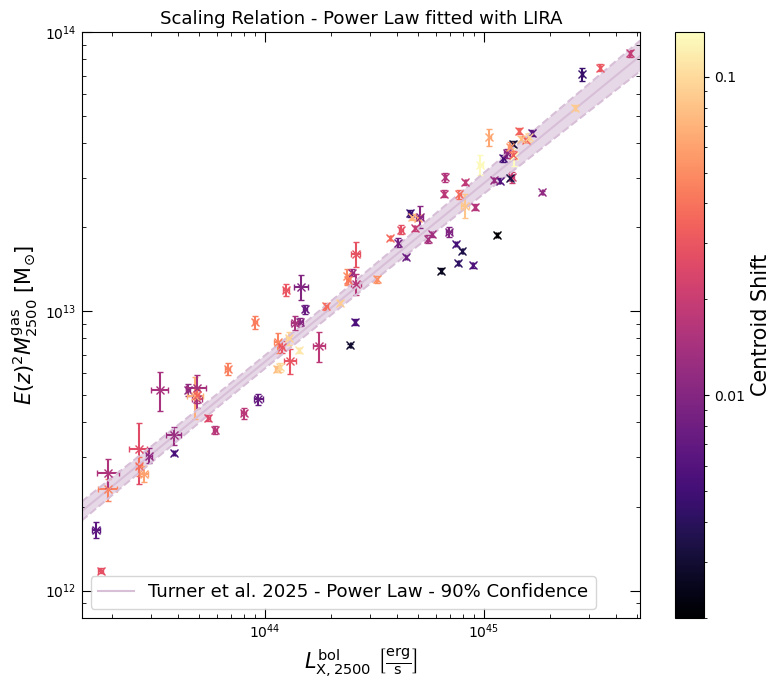

In [27]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mgas2500_lxbol_2500.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
cent_shift = sdssxcs_samp.loc[pnt_samp_ind, 'cen_shift'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mgas2500_lxbol_2500._third_dim_info = cent_shift
mgas2500_lxbol_2500._third_dim_name = "Centroid Shift"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their centroid shift, but also log-scaling the
#  colorbar axis to make differentiating between different centroid shifts easier
mgas2500_lxbol_2500.view(figsize=(8, 7), y_lims=Quantity([0.8e+12, 1e+14], 'Msun'), third_dim_cmap=CEN_SHIFT_CMAP, 
                         third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

#### Concentration

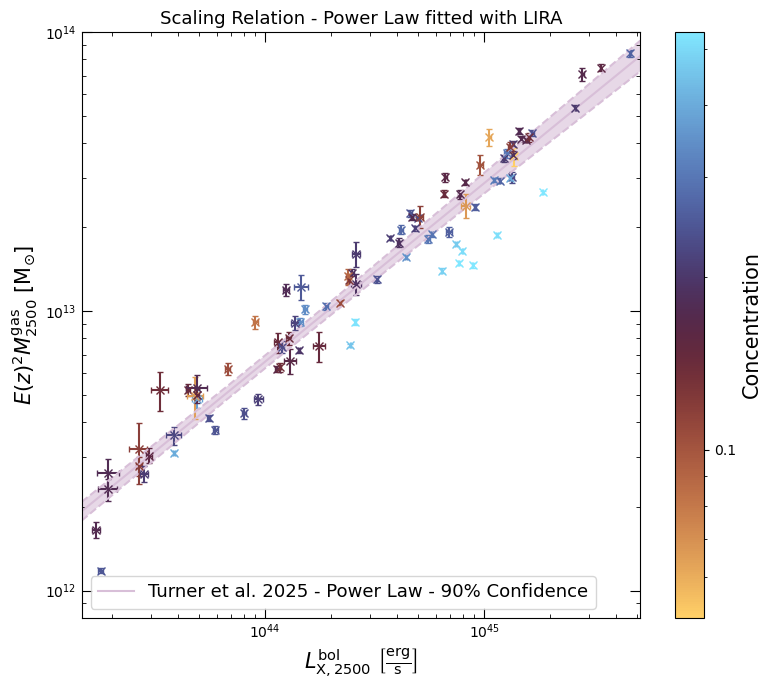

In [28]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mgas2500_lxbol_2500.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
conc = sdssxcs_samp.loc[pnt_samp_ind, 'concentration'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mgas2500_lxbol_2500._third_dim_info = conc
mgas2500_lxbol_2500._third_dim_name = "Concentration"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their concentration, but also log-scaling the
#  colorbar axis to make differentiating between different concentration easier
mgas2500_lxbol_2500.view(figsize=(8, 7), y_lims=Quantity([0.8e+12, 1e+14], 'Msun'), third_dim_cmap=CONC_CMAP, 
                         third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

### $M^{\rm{gas}}_{500}$-$T_{\rm{X,500}}$ 

#### Centroid shift

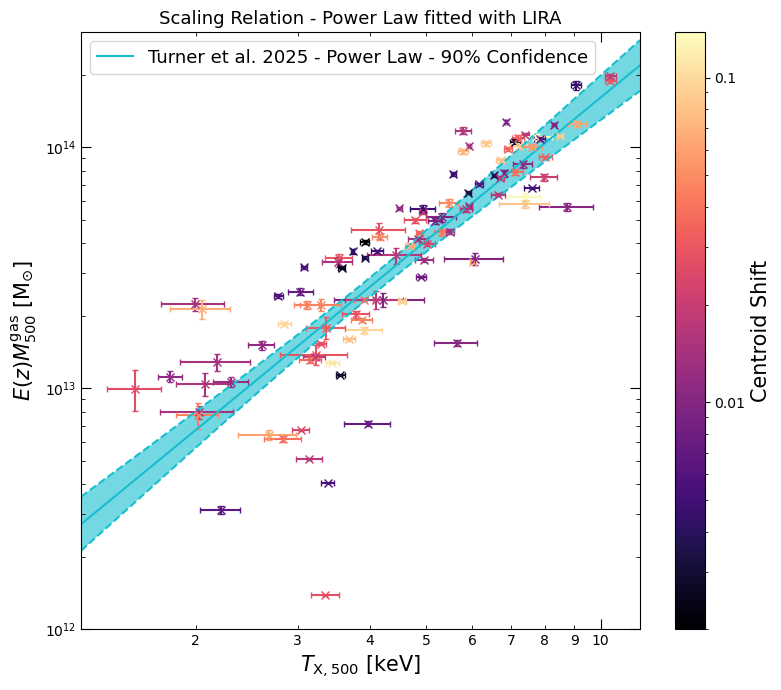

In [29]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mgas500_tx500.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
cent_shift = sdssxcs_samp.loc[pnt_samp_ind, 'cen_shift'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mgas500_tx500._third_dim_info = cent_shift
mgas500_tx500._third_dim_name = "Centroid Shift"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their centroid shift, but also log-scaling the
#  colorbar axis to make differentiating between different centroid shifts easier
mgas500_tx500.view(figsize=(8, 7), y_lims=Quantity([1e+12, 3e+14], 'Msun'), third_dim_cmap=CEN_SHIFT_CMAP, 
                   third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

#### Concentration

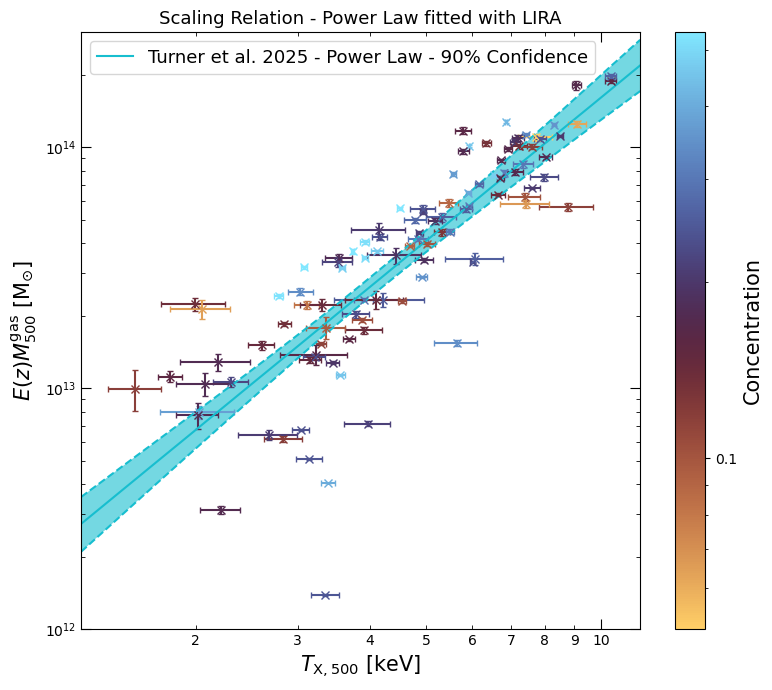

In [30]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mgas500_tx500.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
conc = sdssxcs_samp.loc[pnt_samp_ind, 'concentration'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mgas500_tx500._third_dim_info = conc
mgas500_tx500._third_dim_name = "Concentration"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their concentration, but also log-scaling the
#  colorbar axis to make differentiating between different concentration easier
mgas500_tx500.view(figsize=(8, 7), y_lims=Quantity([1e+12, 3e+14], 'Msun'), third_dim_cmap=CONC_CMAP, 
                   third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

### $M^{\rm{tot}}_{2500}$-$T_{\rm{X,2500}}$ 

#### Centroid shift

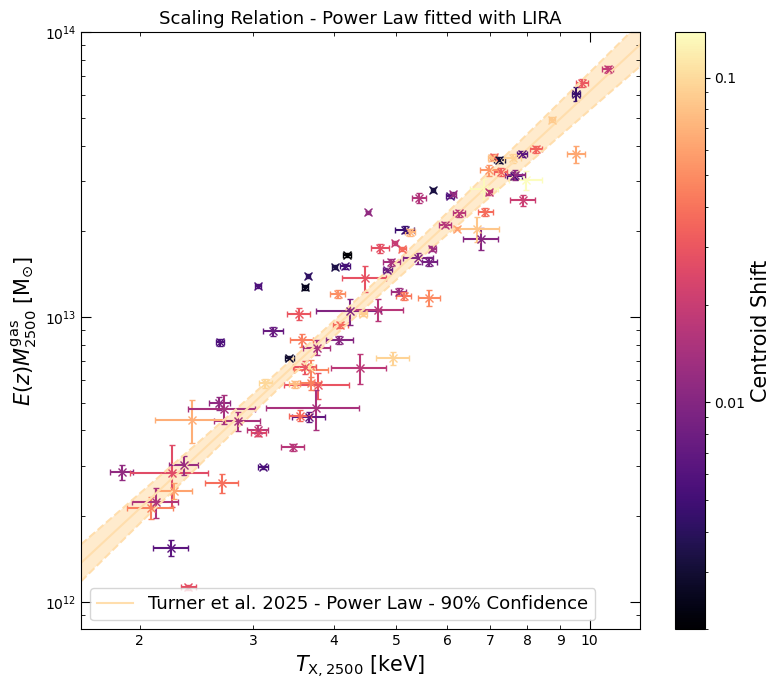

In [31]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mgas2500_tx2500.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
cent_shift = sdssxcs_samp.loc[pnt_samp_ind, 'cen_shift'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mgas2500_tx2500._third_dim_info = cent_shift
mgas2500_tx2500._third_dim_name = "Centroid Shift"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their centroid shift, but also log-scaling the
#  colorbar axis to make differentiating between different centroid shifts easier
mgas2500_tx2500.view(figsize=(8, 7), y_lims=Quantity([0.8e+12, 1e+14], 'Msun'), third_dim_cmap=CEN_SHIFT_CMAP, 
                     third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)

#### Concentration

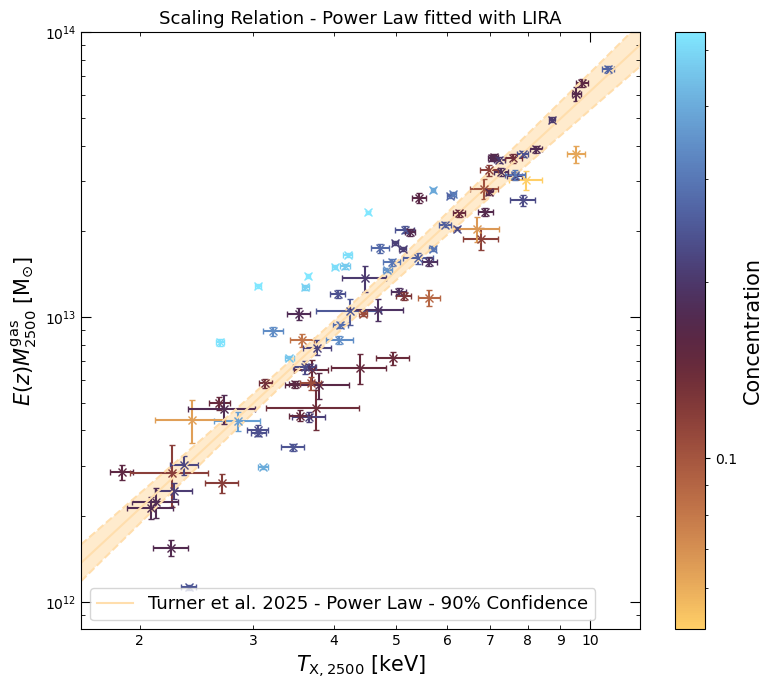

In [32]:
# As the relation is not guaranteed to contain all the data points in the same file, nor to necessarily be in the same order, we 
#  use this search-sorted trick to get the indices in the base sample that correspond to the names given to each datapoint when 
#  the scaling relation was constructed
sort_rel_names = np.argsort(sdssxcs_samp['name'].values)
pnt_samp_ind = sort_rel_names[np.searchsorted(sdssxcs_samp['name'].values, mgas2500_tx2500.point_names, sorter=sort_rel_names)]

# Reads out the morphology parameter we're going to colour the data points by - in the right order
conc = sdssxcs_samp.loc[pnt_samp_ind, 'concentration'].values
# Don't recommend setting attributes directly, but apparently I never added property setters for these when I 
#  wrote this class
mgas2500_tx2500._third_dim_info = conc
mgas2500_tx2500._third_dim_name = "Concentration"

# These set up how the axis labels on the colorbar look - as we are log scaling the third data dimension 
#  this formatter argument will make sure numbers are plotted as 0.01, 0.1, etc. rather than 10^-2, 10^-1, etc. in
#  the case of the third data dimension not covering a parameter range greater than 1.
ax_form = {'major': FuncFormatter(lambda inp, _: '{:g}'.format(inp))}

# We make the visualization, colouring the data points by their concentration, but also log-scaling the
#  colorbar axis to make differentiating between different concentration easier
mgas2500_tx2500.view(figsize=(8, 7), y_lims=Quantity([0.8e+12, 1e+14], 'Msun'), third_dim_cmap=CONC_CMAP, 
                     third_dim_norm_cmap=LogNorm, third_dim_axis_formatters=ax_form)